In [1]:
## Freshwater budget details:
    # Box region: 25-35W, 52-58N
    # Model: 1/4 degree
    # Desnity of freshwater: 1000 Kg/m3
    # Assume constant mixed layer salinity

In [2]:
import cmocean
import numpy as np 
import xarray as xr
import pandas as pd 
import seaborn as sns
import cartopy.crs as ccrs
import statsmodels.api as sm
import matplotlib.pyplot as plt
from IPython.display import HTML
from scipy.stats import linregress 
from nemo_cookbook import NEMODataTree 
from matplotlib.patches import Rectangle
from OceanDataStore import OceanDataCatalog 
from matplotlib.animation import FuncAnimation

In [3]:
## Open 5 Day means to compute delta FC acrosss the month
catalog = OceanDataCatalog(catalog_name="noc-model-stac")
catalog.search(collection='noc-npd-era5', standard_name='sea_surface_temperature')
ds1 = catalog.open_dataset(id=catalog.Items[4].id,
                          start_datetime='1990-01',
                          end_datetime='2024-12')
catalog.search(collection='noc-npd-era5', item_name='domain_cfg')
config = catalog.open_dataset(id=catalog.Items[1].id)

# Merge into a data tree
datasets = {"parent": {"domain": config, "gridT": ds1}}
dt_global = NEMODataTree.from_datasets(datasets = datasets)

# Clip to North Atlantic 
bbox = (-35.0, -25.0, 52.0, 58.0)
dt_clipped = dt_global.clip_grid(grid="gridT", bbox=bbox)

# Add lat and lon as co-ordinates
dt = dt_clipped.add_geoindex(grid="gridT")


            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1y
              Title: eORCA1 ERA5v1 NPD T1y Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics annual mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1m
              Title: eORCA1 ERA5v1 NPD T1m Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics monthly mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca025-era5v1/gn/T1y_3d
              Title: eORCA025 ERA5v1 NPD T1y_3d Icechunk repository
              Description: Icechunk repository containing eORCA025 ERA5v1 

In [4]:
# Compute time series of dFC/dT

dt['gridT']['Freshwater Content'] = ((34.8 - dt['gridT']['sos_abs'])/34.8) * 50
FC_ts = (dt.integral(grid='gridT', var='Freshwater Content', dims=['i', 'j']))
delta_FC = FC_ts.resample(time_counter='ME').map(lambda x: x.isel(time_counter=-1) - x.isel(time_counter=0))
days_in_month = FC_ts.resample(time_counter='ME').map(lambda x: x.time_counter[-1].dt.day - x.time_counter[0].dt.day)
seconds_in_month = days_in_month * 24 * 60 * 60
dFCbydt = (delta_FC / seconds_in_month).compute()

In [5]:
# Save Terms

dFCbydt.to_netcdf('dFCbydt_50m.nc')

In [3]:
# Start from here 

dFCbydt = xr.open_dataset('dFCbydt_50m.nc')['__xarray_dataarray_variable__']
surface_flux = xr.open_dataset('surface_flux_again.nc')['sowaflup']
integrated_MLD = xr.open_dataset('integrated_MLD.nc')['somxl010']
SSTs = xr.open_dataset('Monthly_SSTs.nc')['tos_con']
SSSs = xr.open_dataset('Monthly_SSSs.nc')['sos_abs']
SSSvals = SSSs.values
SSTvals = SSTs.values

In [4]:
residuals = dFCbydt - surface_flux
magnitude_ratios = abs(surface_flux) / abs(residuals)
heatflux_contribution = surface_flux / dFCbydt

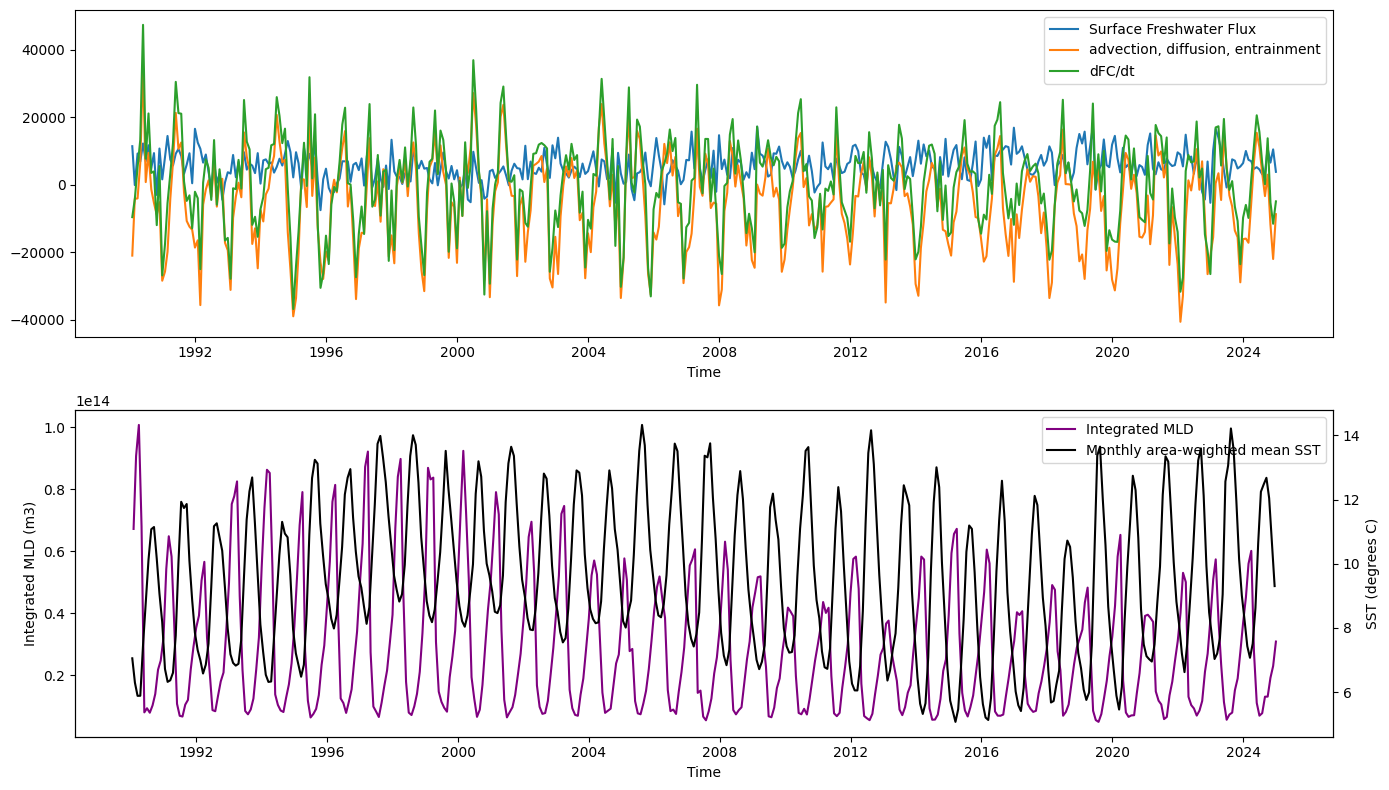

In [6]:
# Surface freshwater flux vs Advwection vs dFC/dt 

fig, ax = plt.subplots(2, 1, figsize = (14, 8))

ax[0].plot(surface_flux['time_counter'], surface_flux, label = 'Surface Freshwater Flux')
ax[0].plot(residuals['time_counter'], residuals, label = 'advection, diffusion, entrainment')
ax[0].plot(dFCbydt['time_counter'], dFCbydt, label = 'dFC/dt')
ax[0].legend(loc = 'best')
# ax[0].set_xlim(np.datetime64('1990-01-01'), np.datetime64('1994-12-31'))
ax[0].set_xlabel('Time')

ax2 = ax[1].twinx()
l1 = ax[1].plot(integrated_MLD['time_counter'], integrated_MLD, label = 'Integrated MLD', color = 'purple')
l2 = ax2.plot(SSTs['time_counter'], SSTs, label = 'Monthly area-weighted mean SST', color = 'k')
ax[1].set_ylabel('Integrated MLD (m3)')
ax2.set_ylabel('SST (degrees C)')
lines = l1 + l2
labels = [l.get_label() for l in lines]
ax[1].legend(lines, labels, loc='best')
# ax[1].set_xlim(np.datetime64('1990-01-01'), np.datetime64('1994-12-31'))
ax[1].set_xlabel('Time')

plt.tight_layout()
plt.show()

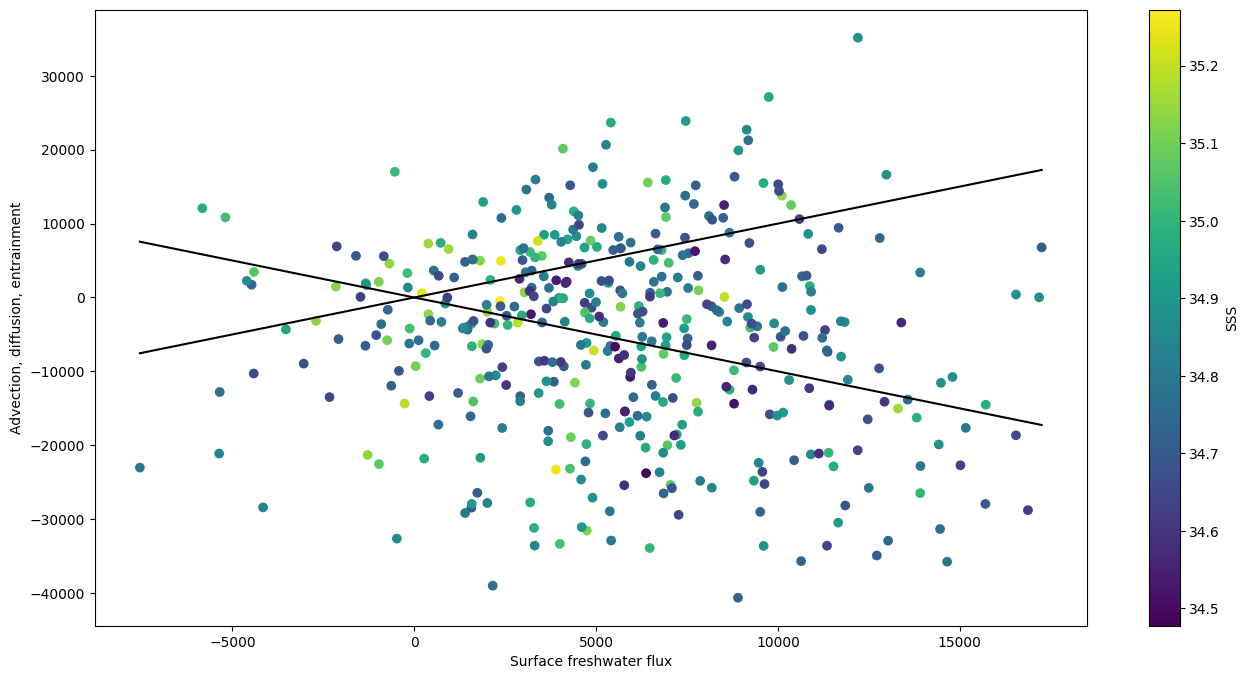

In [9]:
# Josey and Sinha Plot

fig, ax = plt.subplots(figsize = (16, 8))

plt.scatter(surface_flux.values, residuals.values, c = SSSvals, cmap = 'viridis')
plt.xlabel('Surface freshwater flux')
plt.ylabel('Advection, diffusion, entrainment')

xmin = surface_flux.min().item()
xmax = surface_flux.max().item()
x = np.linspace(xmin, xmax, 100)
plt.plot(x, x, color = 'k')
plt.plot(x, -x, color = 'k')
plt.colorbar(ax = ax, label = ('SSS'))

plt.show()

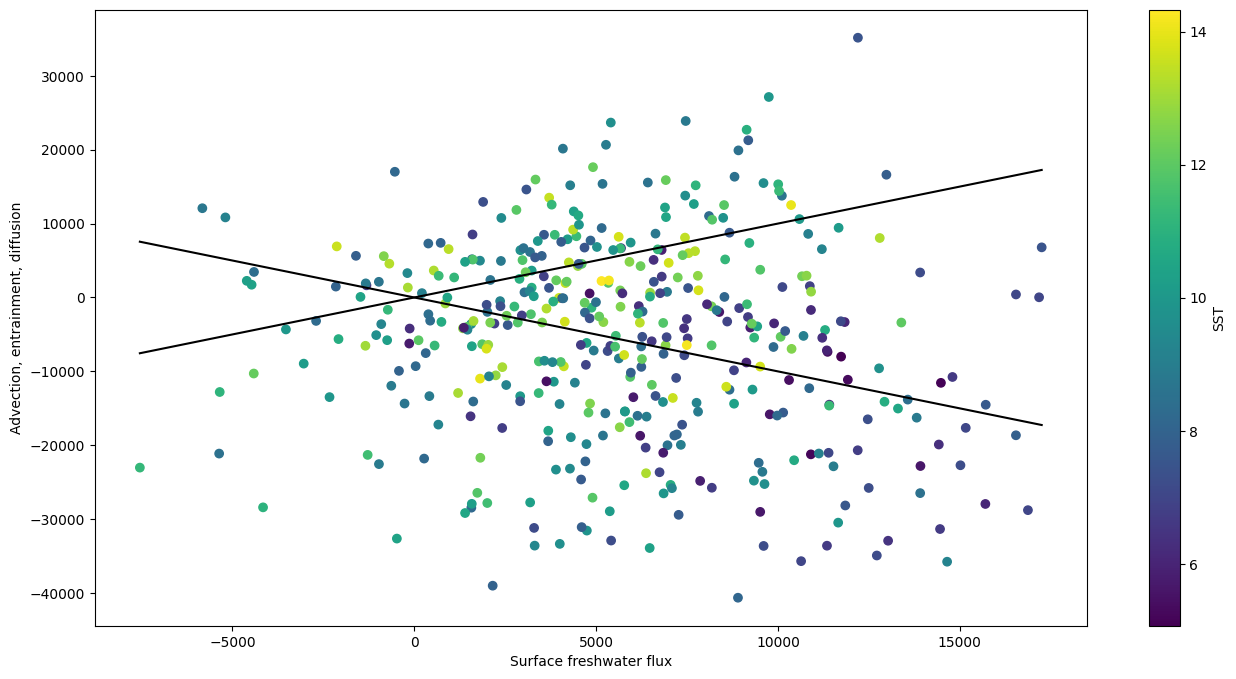

In [10]:
# Josey and Sinha Plot

fig, ax = plt.subplots(figsize = (16, 8))

plt.scatter(surface_flux.values, residuals.values, c = SSTvals, cmap = 'viridis')
plt.xlabel('Surface freshwater flux')
plt.ylabel('Advection, entrainment, diffusion')          

xmin = surface_flux.min().item()
xmax = surface_flux.max().item()
x = np.linspace(xmin, xmax, 100)
plt.plot(x, x, color = 'k')
plt.plot(x, -x, color = 'k')
plt.colorbar(ax = ax, label = ('SST'))

plt.show()

In [11]:
dFCbydt

<xarray.DataArray '__xarray_dataarray_variable__' (time_counter: 420)> Size: 3kB
array([ -9620.805783,  -4328.975502,   5171.109807, ...,  -5283.435746,
       -11576.289782,  -4948.584837], shape=(420,))
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 3kB 1990-01-31 ... 2024-12-31
Attributes:
    units:               g/kg
    online_operation:    average
    interval_operation:  1800 s
    interval_write:      5 d
    cell_methods:        time: mean (interval: 1800 s)
    axis:                T
    time_origin:         1900-01-01 00:00:00
    bounds:              time_counter_bounds